# Create model

In [1]:
# Cell 0 — Lock toàn bộ notebook vào GPU vật lý #5
import os, sys

# ⚠️ Phải chạy trước khi import torch/transformers/... Nếu đã import rồi -> restart kernel.
if 'torch' in sys.modules:
    raise RuntimeError("Hãy Restart Kernel rồi chạy Cell 0 trước mọi import để khóa GPU.")

# Cấu hình môi trường cho tiến trình notebook
os.environ['CUDA_DEVICE_ORDER']    = 'PCI_BUS_ID'  # giữ thứ tự GPU theo PCI id (ổn định)
os.environ['CUDA_VISIBLE_DEVICES'] = '4'           # chỉ expose GPU vật lý #5 -> thành cuda:0 trong tiến trình này

# Bắt đầu import sau khi đã set env
import torch

# Đặt thiết bị mặc định về logical 0 (tức GPU #5 vật lý)
if torch.cuda.is_available():
    torch.cuda.set_device(0)           # chọn logical GPU 0 (mapping tới physical #5)
    try:
        torch.set_default_device('cuda:0')  # PyTorch >= 2.0
    except Exception:
        pass

# Kiểm tra
print("CUDA_VISIBLE_DEVICES =", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("Torch sees", torch.cuda.device_count(), "device(s)")
if torch.cuda.is_available():
    print("current_device (logical) =", torch.cuda.current_device())
    for i in range(torch.cuda.device_count()):
        print(f"  logical {i} -> {torch.cuda.get_device_name(i)}")
else:
    print("CUDA not available -> sẽ chạy CPU")


CUDA_VISIBLE_DEVICES = 4
Torch sees 1 device(s)
current_device (logical) = 0
  logical 0 -> NVIDIA RTX A5000


In [2]:
# Cell 1 — Load LongCLIP từ đường dẫn tuyệt đối
# --- Zero-shot eval: truyền model + preprocess từ cell 1 ---
# import os
# # Ví dụ: chỉ cho phép sử dụng GPU số 1 và 2
# os.environ["CUDA_VISIBLE_DEVICES"] = "5"

import sys
sys.path.append("../..")

from pathlib import Path
import torch
from model import longclip


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def load_longclip(ckpt_path: str, device: str = DEVICE):
    ckpt_path = str(Path(ckpt_path).expanduser())
    if not Path(ckpt_path).exists():
        raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}")

    model, preprocess = longclip.load(ckpt_path, device=device)
    model = model.to(device).eval()
    # tiện cho cell sau
    try:
        model.preprocess = preprocess
    except Exception:
        pass

    print(f"✅ Loaded LongCLIP from: {ckpt_path}\n🖥️ Device: {device}")
    return model, preprocess

# Ví dụ dùng:
model, preprocess = load_longclip("/home/ubuntu/hieu.tq/Git/KDPL_test/KDPL/src/LongCLIPMul_docci/train/results_scaled_data/scale_sharedgpt4v_sparsemax_1000/ckpt/B16-longclip-09-05--07_38_16_-8.pt")


/home/ubuntu/miniconda3/envs/kdpl/lib/python3.8/site-packages/transformers/utils/hub.py:124: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


✅ Loaded LongCLIP from: /home/ubuntu/hieu.tq/Git/KDPL_test/KDPL/src/LongCLIPMul_docci/train/results_scaled_data/scale_sharedgpt4v_sparsemax_1000/ckpt/B16-longclip-09-05--07_38_16_-8.pt
🖥️ Device: cuda


In [63]:
# import os, torch
# os.environ["CUDA_VISIBLE_DEVICES"] = "5"

# print("CUDA_VISIBLE_DEVICES =", os.environ.get("CUDA_VISIBLE_DEVICES"))
# print("Torch sees", torch.cuda.device_count(), "device(s)")
# if torch.cuda.is_available():
#     print("current_device (logical) =", torch.cuda.current_device())
#     for i in range(torch.cuda.device_count()):
#         print(f"  logical {i} ->", torch.cuda.get_device_name(i))


# Imagenet-sub

In [64]:
# --- Zero-shot eval: truyền model + preprocess từ cell 1 ---
# import os
# # Ví dụ: chỉ cho phép sử dụng GPU số 1 và 2
# os.environ["CUDA_VISIBLE_DEVICES"] = "5"

import sys
sys.path.append('../..')

import torch
from types import SimpleNamespace
from tqdm import tqdm

from model import longclip
from classes import imagenet_classes
from data_loader import data_loader, get_label
from templates import imagenet_templates


def zeroshot_classifier(model, classnames, templates, device):
    model.eval()
    with torch.no_grad():
        zs_weights = []
        for classname in tqdm(classnames):
            texts = [tpl.format(classname) for tpl in templates]
            tokens = longclip.tokenize(texts).to(device)
            txt_feats = model.encode_text(tokens)
            txt_feats = txt_feats / txt_feats.norm(dim=-1, keepdim=True)
            class_feat = txt_feats.mean(dim=0)
            class_feat = class_feat / class_feat.norm()
            zs_weights.append(class_feat)
        zs_weights = torch.stack(zs_weights, dim=1).to(device)
    return zs_weights

def evaluate_zeroshot(model,
                      preprocess,
                      data_dir="/home/ubuntu/shared/hieu.tq/imagenet-s/data/ImageNetS919/validation",
                      num_workers=8,
                      batch_size=256,
                      device=None):
    assert preprocess is not None, "`preprocess` must be provided."

    # ✅ Quan trọng: reset default device về CPU để DataLoader/transform không đòi CUDA generator
    try:
        # Chỉ có từ PyTorch 2.0+, nếu không có thì bỏ qua
        import torch
        if hasattr(torch, "set_default_device"):
            torch.set_default_device("cpu")
    except Exception:
        pass

    # Sau đó chọn device cho model/tensor như cũ
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    print("Using:", device)
    model = model.to(device).eval()

    from types import SimpleNamespace
    args = SimpleNamespace(
        data_dir=data_dir,
        num_workers=num_workers,
        batch_size=batch_size,
    )

    softmax = torch.nn.Softmax(dim=1)
    loader, _ = data_loader(preprocess, args)

    zs_weights = zeroshot_classifier(model, imagenet_classes, imagenet_templates, device)

    total_num = 0
    true_num = 0

    with torch.no_grad():
        for images, targets, paths in tqdm(loader):
            images = images.to(device, non_blocking=True)

            img_feats = model.encode_image(images)
            img_feats = img_feats / img_feats.norm(dim=-1, keepdim=True)

            logits = 100.0 * (img_feats @ zs_weights)
            probs = softmax(logits)
            pred = torch.argmax(probs, dim=1)

            for i in range(pred.shape[0]):
                label = get_label(targets[i]).item()
                if pred[i].item() == label:
                    true_num += 1
                total_num += 1

    acc = true_num / total_num if total_num > 0 else 0.0
    print(f"Zero-shot top-1 accuracy: {acc:.4f}")
    return acc


In [65]:
acc = evaluate_zeroshot(model, preprocess)

Using: cuda


100%|██████████| 49/49 [00:23<00:00,  2.06it/s]

Zero-shot top-1 accuracy: 0.7255


# Imagenet-o

In [66]:
# --- Zero-shot eval (ImageNet-O): truyền model + preprocess từ cell 1 ---
import sys
sys.path.append('../..')

import torch
from types import SimpleNamespace
from tqdm import tqdm

from model import longclip
from classes import imagenet_classes
from data_loader import data_loader, get_label
from templates import imagenet_templates


def zeroshot_classifier(model, classnames, templates, device):
    model.eval()
    with torch.no_grad():
        zs_weights = []
        for classname in tqdm(classnames):
            texts = [template.format(classname) for template in templates]  # format with class
            tokens = longclip.tokenize(texts).to(device)                   # tokenize -> device
            class_embs = model.encode_text(tokens)                         # text encode
            class_embs = class_embs / class_embs.norm(dim=-1, keepdim=True)
            class_emb = class_embs.mean(dim=0)
            class_emb = class_emb / class_emb.norm()
            zs_weights.append(class_emb)
        zs_weights = torch.stack(zs_weights, dim=1).to(device)
    return zs_weights


def run_zeroshot(model,
                 preprocess,
                 data_dir="/home/ubuntu/shared/hieu.tq/data/imagenet-o/imagenet-o",
                 num_workers=8,
                 batch_size=256,
                 device=None):
    """
    Truyền `model` và `preprocess` đã có ở cell 1.
    Logic còn lại giữ nguyên như script gốc.
    """
    assert preprocess is not None, "`preprocess` must be provided."

    # ✅ Quan trọng: reset default device về CPU để DataLoader/transform không đòi CUDA generator
    try:
        # Chỉ có từ PyTorch 2.0+, nếu không có thì bỏ qua
        import torch
        if hasattr(torch, "set_default_device"):
            torch.set_default_device("cpu")
    except Exception:
        pass


    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device).eval()

    # Lắp args giống argparse trong ví dụ
    args = SimpleNamespace(
        data_dir=data_dir,
        num_workers=num_workers,
        batch_size=batch_size,
    )

    softmax = torch.nn.Softmax(dim=1)
    loader, dataset = data_loader(preprocess, args)

    # Tạo zero-shot classifier
    zs_weights = zeroshot_classifier(model, imagenet_classes, imagenet_templates, device)

    total_num, true_num = 0, 0

    with torch.no_grad():
        for i, (images, targets, paths) in enumerate(tqdm(loader)):
            images = images.to(device)

            # Predict
            image_features = model.encode_image(images)
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)
            logits = 100.0 * (image_features @ zs_weights)
            probs = softmax(logits)
            pred = torch.argmax(probs, dim=1)

            total_len = pred.shape[0]
            for j in range(total_len):
                label = get_label(targets[j]).item()
                if pred[j].item() == label:
                    true_num += 1
                total_num += 1

            # # Optionally, save output to file.
            # save_to_file(logits, targets, paths)

    acc = true_num / total_num if total_num > 0 else 0.0
    print(acc)
    return acc

In [67]:
acc = run_zeroshot(model, preprocess)


  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:06<00:00,  1.25it/s]

0.2705


# Imagenet-v2

In [68]:
# --- Zero-shot eval (ImageNet-V2): truyền model + preprocess từ cell 1 ---
import sys
sys.path.append('../..')

import torch
from types import SimpleNamespace
from tqdm import tqdm

from model import longclip
from classes import imagenet_classes
from data_loader import data_loader
from templates import imagenet_templates


def zeroshot_classifier(model, classnames, templates, device):
    model.eval()
    with torch.no_grad():
        zs_weights = []
        for classname in tqdm(classnames):
            texts = [template.format(classname) for template in templates]  # format with class
            tokens = longclip.tokenize(texts).to(device)                   # tokenize -> device
            class_embs = model.encode_text(tokens)                         # text encode
            class_embs = class_embs / class_embs.norm(dim=-1, keepdim=True)
            class_emb = class_embs.mean(dim=0)
            class_emb = class_emb / class_emb.norm()
            zs_weights.append(class_emb)
        zs_weights = torch.stack(zs_weights, dim=1).to(device)
    return zs_weights


def run_zeroshot_imagenetv2(model,
                            preprocess,
                            data_dir="/home/ubuntu/shared/hieu.tq/data/ImageNetV2/imagenetv2-top-images-format-val",
                            num_workers=8,
                            batch_size=256,
                            device=None):
    """
    Truyền `model` và `preprocess` đã có ở cell 1.
    Giữ nguyên xử lý nhãn: so sánh trực tiếp với int(label).
    """
    assert preprocess is not None, "`preprocess` must be provided."

    # ✅ Quan trọng: reset default device về CPU để DataLoader/transform không đòi CUDA generator
    try:
        # Chỉ có từ PyTorch 2.0+, nếu không có thì bỏ qua
        import torch
        if hasattr(torch, "set_default_device"):
            torch.set_default_device("cpu")
    except Exception:
        pass

    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device).eval()

    # Dựng args tương đương argparse của script gốc
    args = SimpleNamespace(
        data_dir=data_dir,
        num_workers=num_workers,
        batch_size=batch_size,
    )

    softmax = torch.nn.Softmax(dim=1)
    loader, dataset = data_loader(preprocess, args)

    # Zero-shot classifier
    zs_weights = zeroshot_classifier(model, imagenet_classes, imagenet_templates, device)

    total_num, true_num = 0, 0

    with torch.no_grad():
        for step, (images, targets, paths) in enumerate(tqdm(loader)):
            images = images.to(device)

            # Predict
            image_features = model.encode_image(images)
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)
            logits = 100.0 * (image_features @ zs_weights)
            probs = softmax(logits)
            pred = torch.argmax(probs, dim=1)

            # Đếm đúng/sai (ImageNet-V2: label đã là chỉ số lớp)
            for j in range(pred.shape[0]):
                if pred[j].item() == int(targets[j]):
                    true_num += 1
                total_num += 1

            # # Optionally save:
            # save_to_file(logits, targets, paths)

    acc = true_num / total_num if total_num > 0 else 0.0
    print(acc)
    return acc


In [69]:
acc = run_zeroshot_imagenetv2(model, preprocess)

100%|██████████| 40/40 [00:18<00:00,  2.21it/s]

0.7277


# Urban

In [70]:
# ===== Urban1k retrieval eval — dùng model & preprocess từ cell 1 =====
import os
from pathlib import Path
from typing import Optional, List, Dict

import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm import tqdm

# LongCLIP tokenizer
try:
    from model_sail import longclip
except ImportError:
    from model import longclip  # fallback


# -----------------------------
# Dataset: dùng preprocess bạn truyền vào
# -----------------------------
class Urban1kDataset(Dataset):
    """
    Urban1k: mỗi ảnh có 1 caption trùng tên file (không đuôi).
    Trả về: (image_tensor, caption, "None", "None", "None") để tương thích collate cũ.
    """
    def __init__(self, root_dir: str, preprocess, max_items: Optional[int] = None):
        self.image_dir = os.path.join(root_dir, "image")
        self.caption_dir = os.path.join(root_dir, "caption")
        assert os.path.isdir(self.image_dir), f"Not found: {self.image_dir}"
        assert os.path.isdir(self.caption_dir), f"Not found: {self.caption_dir}"

        self.ids = sorted(
            fname[:-4]
            for fname in os.listdir(self.caption_dir)
            if fname.endswith(".txt")
        )
        if max_items is not None:
            self.ids = self.ids[:max_items]

        self.preprocess = preprocess

    def __len__(self) -> int:
        return len(self.ids)

    def __getitem__(self, index: int):
        item_id = self.ids[index]

        # Caption
        with open(os.path.join(self.caption_dir, f"{item_id}.txt"), "r", encoding="utf-8") as f:
            caption = f.read().strip().replace("\n", " ")

        # Image (.jpg theo cấu trúc Urban1k)
        img_path = os.path.join(self.image_dir, f"{item_id}.jpg")
        image = Image.open(img_path).convert("RGB")
        image_t = self.preprocess(image)

        return image_t, caption, "None", "None", "None"


def build_loader(dataset: Dataset, batch_size: int, num_workers: int = 8) -> DataLoader:
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        persistent_workers=(num_workers > 0),
    )


# -----------------------------
# Helpers & splitter
# -----------------------------
def _encode_image(model, images):
    out = model.encode_image(images)
    return out[0] if isinstance(out, (tuple, list)) else out

def _encode_text(model, tokens):
    out = model.encode_text(tokens)
    return out[0] if isinstance(out, (tuple, list)) else out

def split_into_detail_captions(text: str, max_details: int = 4):
    """
    Tách caption thành tối đa `max_details` câu ngắn theo dấu . ! ? ; : hoặc xuống dòng.
    Pad "" nếu thiếu.
    """
    import re
    if not isinstance(text, str):
        text = str(text)
    parts = [p.strip() for p in re.split(r'[\.!\?;:\n]+', text) if p.strip()]
    parts = parts[:max_details]
    while len(parts) < max_details:
        parts.append("")
    return parts


# -----------------------------
# Evaluation core (như test_epoch nhưng dùng trực tiếp `model`)
# -----------------------------
@torch.no_grad()
def test_epoch_with_model_urban1k(model, dataloader, device, max_details: int = 4):
    model.eval()
    model = model.to(device)

    im_feats_list     = []
    long_feats_list   = []
    txt_feats_lists   = {j: [] for j in range(max_details)}

    for batch in tqdm(dataloader, desc="Extracting features"):
        # Dataloader trả: (images, long_texts, _, _, _)
        images, long_texts = batch[0], batch[1]
        images = images.to(device, non_blocking=True)

        # Image features
        feats_i = _encode_image(model, images)
        feats_i = feats_i / feats_i.norm(dim=-1, keepdim=True)
        im_feats_list.append(feats_i)

        # Full-text features
        tokens_long = longclip.tokenize(list(long_texts), truncate=True).to(device)
        feats_long = _encode_text(model, tokens_long)
        feats_long = feats_long / feats_long.norm(dim=-1, keepdim=True)
        long_feats_list.append(feats_long)

        # Detail captions (per batch)
        caps_batch = [split_into_detail_captions(t, max_details=max_details) for t in long_texts]
        for j in range(max_details):
            texts_j = [c[j] if j < len(c) else "" for c in caps_batch]
            toks_j = longclip.tokenize(texts_j, truncate=True).to(device)
            fts_j = _encode_text(model, toks_j)
            fts_j = fts_j / fts_j.norm(dim=-1, keepdim=True)
            txt_feats_lists[j].append(fts_j)

    # Concat
    im_feats_all   = torch.cat(im_feats_list, dim=0)
    long_all       = torch.cat(long_feats_list, dim=0)
    txt_all_lists  = [torch.cat(txt_feats_lists[j], dim=0) for j in range(max_details)]

    # Similarities
    sims_t2i = {
        "long":    long_all @ im_feats_all.T,
        **{f"detail_{j+1}": txt_all_lists[j] @ im_feats_all.T for j in range(max_details)}
    }
    sims_i2t_long = im_feats_all @ long_all.T

    # Recall@K (1-1 mapping ảnh↔caption theo thứ tự)
    N = im_feats_all.size(0)
    target = torch.arange(N, device=im_feats_all.device)
    ks = [1, 5, 25, 50]

    acc = {}
    # Text→Image (full + detail)
    for name, sims in sims_t2i.items():
        for k in ks:
            topk_inds = sims.topk(k, dim=1).indices              # [N, k]
            hits = topk_inds.eq(target.unsqueeze(1)).any(dim=1).float().mean().item()
            acc[f"{name}_t2i_R{k}"] = hits

    # Image→Text (full)
    for k in ks:
        topk_inds = sims_i2t_long.topk(k, dim=1).indices
        hits = topk_inds.eq(target.unsqueeze(1)).any(dim=1).float().mean().item()
        acc[f"long_i2t_R{k}"] = hits

    # Print summary
    print("\n—— Urban1k Metrics ——")
    for k in ks:
        print(f"▶ Full Text → Image @ {k:2}: {acc[f'long_t2i_R{k}']:.4%}")
    for k in ks:
        print(f"▶ Image → Full Text @ {k:2}: {acc[f'long_i2t_R{k}']:.4%}")
    print("—" * 30)
    return acc


# -----------------------------
# Runner cho notebook
# -----------------------------
def run_urban1k_eval(
    model,
    preprocess,
    data_root="/home/ubuntu/shared/hieu.tq/Urban1k/Urban1k",
    batch_size=64,
    num_workers=32,
    device=None,
    max_items=None,
    max_details=4,
):
    """
    Dùng `model` & `preprocess` từ cell 1. Không dùng CLIP_Clean_Train.
    """
    assert preprocess is not None, "`preprocess` must be provided."

    # ✅ Quan trọng: reset default device về CPU để DataLoader/transform không đòi CUDA generator
    try:
        # Chỉ có từ PyTorch 2.0+, nếu không có thì bỏ qua
        import torch
        if hasattr(torch, "set_default_device"):
            torch.set_default_device("cpu")
    except Exception:
        pass

    device = device or ("cuda" if torch.cuda.is_available() else "cpu")

    ds = Urban1kDataset(root_dir=data_root, preprocess=preprocess, max_items=max_items)
    dl = build_loader(ds, batch_size=batch_size, num_workers=num_workers)

    print(f"Số mẫu Urban1k: {len(ds)}")
    print(f"Số batch: {len(dl)}")

    metrics = test_epoch_with_model_urban1k(model, dl, device=device, max_details=max_details)
    print(f"Individual metrics: {metrics}")
    return metrics


In [71]:
metrics = run_urban1k_eval(model, preprocess)

Số mẫu Urban1k: 1000
Số batch: 16


Extracting features:   0%|          | 0/16 [00:00<?, ?it/s]

Extracting features: 100%|██████████| 16/16 [00:09<00:00,  1.62it/s]


—— Urban1k Metrics ——
▶ Full Text → Image @  1: 68.8000%
▶ Full Text → Image @  5: 88.6000%
▶ Full Text → Image @ 25: 97.1000%
▶ Full Text → Image @ 50: 98.3000%
▶ Image → Full Text @  1: 78.1000%
▶ Image → Full Text @  5: 94.1000%
▶ Image → Full Text @ 25: 99.1000%
▶ Image → Full Text @ 50: 100.0000%
——————————————————————————————
Individual metrics: {'long_t2i_R1': 0.6880000233650208, 'long_t2i_R5': 0.8860000371932983, 'long_t2i_R25': 0.971000075340271, 'long_t2i_R50': 0.9830000400543213, 'detail_1_t2i_R1': 0.3710000216960907, 'detail_1_t2i_R5': 0.5830000042915344, 'detail_1_t2i_R25': 0.7750000357627869, 'detail_1_t2i_R50': 0.8480000495910645, 'detail_2_t2i_R1': 0.23600001633167267, 'detail_2_t2i_R5': 0.43300002813339233, 'detail_2_t2i_R25': 0.6790000200271606, 'detail_2_t2i_R50': 0.7700000405311584, 'detail_3_t2i_R1': 0.12800000607967377, 'detail_3_t2i_R5': 0.27400001883506775, 'detail_3_t2i_R25': 0.46700000762939453, 'detail_3_t2i_R50': 0.5920000076293945, 'detail_4_t2i_R1': 0.074

# Flickr

In [ ]:
# # ===== Zero-shot retrieval eval (Flickr30k) - dùng model & preprocess từ cell 1 =====
# import os, json
# import pandas as pd
# from PIL import Image
# import torch
# from torch.utils.data import Dataset, DataLoader
# from types import SimpleNamespace
# from tqdm import tqdm

# sys.path.append('../..')
# from model import longclip  # dùng tokenizer của LongCLIP

# # -----------------------------
# # Dataset: dùng preprocess do bạn truyền vào (không tự clip.load)
# # -----------------------------
# class Flickr30kPairDataset(Dataset):
#     """
#     Mỗi hàng là 1 (image, caption) sample. Mặc định lấy caption[0] từ cột 'raw' (list captions).
#     Trả về: image_tensor, caption_long, caption_short, img_path, split
#     """
#     def __init__(
#         self,
#         csv_path: str,
#         root_dir: str,
#         preprocess,               # bắt buộc: transform từ cell 1
#         split: str = None,        # 'train' | 'val' | 'test' | None (lấy tất)
#         max_items: int = None,
#     ):
#         super().__init__()
#         self.preprocess = preprocess

#         df = pd.read_csv(csv_path)
#         if split is not None:
#             df = df[df["split"] == split]
#         if max_items is not None:
#             df = df.iloc[:max_items]
#         df = df.reset_index(drop=True)

#         samples = []
#         for _, row in df.iterrows():
#             img_path = os.path.join(root_dir, "flickr30k-images", row["filename"])
#             caps = json.loads(row["raw"])
#             cap0 = caps[0].strip() if isinstance(caps, list) and len(caps) > 0 else str(row.get("sentence", "")).strip()
#             samples.append({
#                 "img_path": img_path,
#                 "caption": cap0,
#                 "split": row["split"],
#                 "img_id": row.get("img_id", None),
#             })
#         self.samples = samples

#     def __len__(self):
#         return len(self.samples)

#     def __getitem__(self, idx):
#         item = self.samples[idx]
#         image = Image.open(item["img_path"]).convert("RGB")
#         image_tensor = self.preprocess(image)
#         caption_long = item["caption"]
#         caption_short = item["caption"]
#         return image_tensor, caption_long, caption_short, item["img_path"], item["split"]


# # -----------------------------
# # Helpers: encode wrappers & tách câu chi tiết
# # -----------------------------
# def _encode_image(model, images):
#     out = model.encode_image(images)
#     return out[0] if isinstance(out, (tuple, list)) else out

# def _encode_text(model, tokens):
#     out = model.encode_text(tokens)
#     return out[0] if isinstance(out, (tuple, list)) else out

# def split_into_detail_captions(text: str, max_details: int = 4):
#     """
#     Tách caption dài thành tối đa `max_details` câu ngắn.
#     Mặc định: tách theo dấu câu . ! ? ; : hoặc xuống dòng. Nếu thiếu thì pad "".
#     Bạn có thể thay bằng splitter riêng của bạn nếu có.
#     """
#     if not isinstance(text, str):
#         text = str(text)
#     # tách thô, giữ nội dung ngắn gọn
#     import re
#     parts = [p.strip() for p in re.split(r'[\.!\?;:\n]+', text) if p.strip()]
#     parts = parts[:max_details]
#     while len(parts) < max_details:
#         parts.append("")
#     return parts


# # -----------------------------
# # Evaluation core (thay cho trainer.test_epoch)
# # -----------------------------
# def test_epoch_with_model(model, dataloader, device, max_details: int = 4):
#     model.eval()
#     model = model.to(device)

#     im_feats_list     = []
#     im_paths_list     = []
#     long_feats_list   = []
#     txt_feats_lists   = {j: [] for j in range(max_details)}

#     with torch.no_grad():
#         for images, long_texts, _, image_paths, _ in tqdm(dataloader, desc="Extracting features"):
#             im_paths_list.extend(image_paths)
#             images = images.to(device, non_blocking=True)

#             # Image features
#             feats_i = _encode_image(model, images)
#             feats_i = feats_i / feats_i.norm(dim=-1, keepdim=True)
#             im_feats_list.append(feats_i)

#             # Full-text features
#             tokens_long = longclip.tokenize(list(long_texts), truncate=True).to(device)
#             feats_long = _encode_text(model, tokens_long)
#             feats_long = feats_long / feats_long.norm(dim=-1, keepdim=True)
#             long_feats_list.append(feats_long)

#             # Detail captions (per batch)
#             caps_batch = [split_into_detail_captions(t, max_details=max_details) for t in long_texts]
#             for j in range(max_details):
#                 texts_j = [c[j] if j < len(c) else "" for c in caps_batch]
#                 toks_j = longclip.tokenize(texts_j, truncate=True).to(device)
#                 fts_j = _encode_text(model, toks_j)
#                 fts_j = fts_j / fts_j.norm(dim=-1, keepdim=True)
#                 txt_feats_lists[j].append(fts_j)

#     # Concat all features
#     im_feats_all   = torch.cat(im_feats_list, dim=0)
#     long_all       = torch.cat(long_feats_list, dim=0)
#     txt_all_lists  = [torch.cat(txt_feats_lists[j], dim=0) for j in range(max_details)]

#     # Similarity matrices
#     sims_t2i = {
#         "long":    long_all @ im_feats_all.T,
#         **{f"detail_{j+1}": txt_all_lists[j] @ im_feats_all.T for j in range(max_details)}
#     }
#     sims_i2t_long = im_feats_all @ long_all.T

#     # Recall@K
#     N = im_feats_all.size(0)
#     target = torch.arange(N, device=im_feats_all.device)
#     ks = [1, 5, 25, 50]

#     acc = {}
#     # Text → Image
#     for name, sims in sims_t2i.items():
#         for k in ks:
#             topk_inds = sims.topk(k, dim=1).indices
#             hits = topk_inds.eq(target.unsqueeze(1)).any(dim=1).float().mean().item()
#             acc[f"{name}_t2i_R{k}"] = hits

#     # Image → Text (full)
#     for k in ks:
#         topk_inds = sims_i2t_long.topk(k, dim=1).indices
#         hits = topk_inds.eq(target.unsqueeze(1)).any(dim=1).float().mean().item()
#         acc[f"long_i2t_R{k}"] = hits

#     # Print summary
#     print("\n—— Test Epoch Metrics ——")
#     for k in ks:
#         print(f"▶ Full Text → Image @ {k:2}: {acc[f'long_t2i_R{k}']:.4%}")
#     for k in ks:
#         print(f"▶ Image → Full Text @ {k:2}: {acc[f'long_i2t_R{k}']:.4%}")
#     print("—" * 30)
#     return acc


# # -----------------------------
# # Runner cho notebook
# # -----------------------------
# def run_flickr30k_eval(
#     model,
#     preprocess,
#     csv_path="/home/ubuntu/shared/hieu.tq/flickr30k/flickr_annotations_30k.csv",
#     root_dir="/home/ubuntu/shared/hieu.tq/flickr30k",
#     split="test",
#     batch_size=64,
#     num_workers=32,
#     device=None,
#     max_items=None,
#     max_details=4,
# ):
#     """
#     Dùng model & preprocess đã có (cell 1). Không cần CLIP_Clean_Train hay load ckpt.
#     """
#     assert preprocess is not None, "`preprocess` must be provided."

#     # ✅ Quan trọng: reset default device về CPU để DataLoader/transform không đòi CUDA generator
#     try:
#         # Chỉ có từ PyTorch 2.0+, nếu không có thì bỏ qua
#         import torch
#         if hasattr(torch, "set_default_device"):
#             torch.set_default_device("cpu")
#     except Exception:
#         pass

#     device = device or ("cuda" if torch.cuda.is_available() else "cpu")

#     test_ds = Flickr30kPairDataset(
#         csv_path=csv_path,
#         root_dir=root_dir,
#         preprocess=preprocess,
#         split=split,
#         max_items=max_items,
#     )

#     test_loader = DataLoader(
#         test_ds,
#         batch_size=batch_size,
#         shuffle=False,
#         num_workers=num_workers,
#         pin_memory=True,
#         persistent_workers=(num_workers > 0),
#     )

#     print(f"Số mẫu trong test set: {len(test_loader.dataset)}")
#     print(f"Số batch trong test loader: {len(test_loader)}")

#     metrics = test_epoch_with_model(model, test_loader, device=device, max_details=max_details)
#     print(f"Individual metrics: {metrics}")
#     return metrics


In [ ]:
# metrics = run_flickr30k_eval(model, preprocess)

Số mẫu trong test set: 1000
Số batch trong test loader: 16


Extracting features: 100%|██████████| 16/16 [00:09<00:00,  1.69it/s]


—— Test Epoch Metrics ——
▶ Full Text → Image @  1: 74.1000%
▶ Full Text → Image @  5: 93.1000%
▶ Full Text → Image @ 25: 98.8000%
▶ Full Text → Image @ 50: 99.7000%
▶ Image → Full Text @  1: 76.8000%
▶ Image → Full Text @  5: 94.3000%
▶ Image → Full Text @ 25: 99.4000%
▶ Image → Full Text @ 50: 99.7000%
——————————————————————————————
Individual metrics: {'long_t2i_R1': 0.7410000562667847, 'long_t2i_R5': 0.9310000538825989, 'long_t2i_R25': 0.9880000352859497, 'long_t2i_R50': 0.9970000386238098, 'detail_1_t2i_R1': 0.7390000224113464, 'detail_1_t2i_R5': 0.9320000410079956, 'detail_1_t2i_R25': 0.987000048160553, 'detail_1_t2i_R50': 0.9970000386238098, 'detail_2_t2i_R1': 0.005000000353902578, 'detail_2_t2i_R5': 0.010000000707805157, 'detail_2_t2i_R25': 0.030000001192092896, 'detail_2_t2i_R50': 0.05700000375509262, 'detail_3_t2i_R1': 0.0010000000474974513, 'detail_3_t2i_R5': 0.006000000052154064, 'detail_3_t2i_R25': 0.026000000536441803, 'detail_3_t2i_R50': 0.05100000277161598, 'detail_4_t2

In [7]:
# ===== Flickr30k retrieval eval (multi-caption-per-image, cached image feats) =====
import os, sys, json
from pathlib import Path
from typing import Optional, Dict, List

import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm import tqdm

# Cho phép import module model/longclip ở repo gốc
sys.path.append('../..')
from model import longclip  # dùng tokenizer của LongCLIP

# ────────────────────────────────────────────────────────────────────────────────
# Dataset: MỖI CAPTION là 1 sample (giống COCO multi-caption)
# Trả về: image_tensor, caption (str), image_id (str)
# ────────────────────────────────────────────────────────────────────────────────
class Flickr30kAllCaptionsDataset(Dataset):
    def __init__(
        self,
        csv_path: str,
        root_dir: str,
        preprocess,               # bắt buộc: transform từ cell 1 / model.preprocess
        split: Optional[str] = "test",  # 'train' | 'val' | 'test' | None (lấy tất)
        max_items: Optional[int] = None,
    ):
        super().__init__()
        assert preprocess is not None, "`preprocess` must be provided."
        self.preprocess = preprocess

        df = pd.read_csv(csv_path)
        if split is not None:
            df = df[df["split"] == split].copy()

        samples = []
        for _, row in df.iterrows():
            filename = str(row["filename"])
            img_path = os.path.join(root_dir, "flickr30k-images", filename)

            # id ảnh: ưu tiên cột 'img_id' nếu có, nếu không dùng stem của filename
            img_id = str(row["img_id"]) if "img_id" in row and pd.notna(row["img_id"]) \
                    else Path(filename).stem

            # cột 'raw' là list JSON các caption
            caps = []
            try:
                caps = json.loads(row["raw"]) if pd.notna(row["raw"]) else []
                if not isinstance(caps, list):
                    caps = [str(caps)]
            except Exception:
                # fallback: nếu không parse được, thử cột 'sentence'
                sent = row.get("sentence", "")
                caps = [str(sent)] if pd.notna(sent) and str(sent).strip() else []

            # thêm từng caption thành 1 sample
            for cap in caps:
                cap = str(cap).replace("\n", " ").strip()
                if not cap:
                    continue
                samples.append({
                    "img_path": img_path,
                    "image_id": img_id,
                    "caption": cap,
                })

        if max_items is not None:
            samples = samples[: max_items]

        self.samples = samples

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        image = Image.open(s["img_path"]).convert("RGB")
        return self.preprocess(image), s["caption"], s["image_id"]


# ────────────────────────────────────────────────────────────────────────────────
# Encode helpers: an toàn nếu model.encode_* trả tuple (feats, extras)
# ────────────────────────────────────────────────────────────────────────────────
def _encode_image(model, images):
    out = model.encode_image(images)
    return out[0] if isinstance(out, (tuple, list)) else out

def _encode_text(model, tokens):
    out = model.encode_text(tokens)
    return out[0] if isinstance(out, (tuple, list)) else out


# ────────────────────────────────────────────────────────────────────────────────
# Evaluation (multi-caption-per-image safe, cache image features)
# ────────────────────────────────────────────────────────────────────────────────
@torch.no_grad()
def evaluate_flickr30k_multicap(model, dataloader, device="cuda"):
    model.eval()
    model = model.to(device)

    def _cpu_fp32(x: torch.Tensor) -> torch.Tensor:
        return x.detach().to("cpu", dtype=torch.float32)

    img_feat_cache: Dict[str, torch.Tensor] = {}
    txt_feats_parts: List[torch.Tensor] = []
    cap2img: List[str] = []

    for imgs, caps, img_ids in tqdm(dataloader, desc="Extracting features"):
        # 1) Encode ảnh (chỉ ảnh mới)
        new_ids, new_imgs = [], []
        for _img, _id in zip(imgs, img_ids):
            if _id not in img_feat_cache:
                new_ids.append(_id); new_imgs.append(_img)
        if new_imgs:
            batch_imgs = torch.stack(new_imgs).to(device, non_blocking=True)
            feats_i = F.normalize(_encode_image(model, batch_imgs), dim=-1)
            feats_i = _cpu_fp32(feats_i)
            for _id, _f in zip(new_ids, feats_i):
                img_feat_cache[_id] = _f

        # 2) Encode text
        tokens = longclip.tokenize(list(caps), truncate=True).to(device)
        feats_t = F.normalize(_encode_text(model, tokens), dim=-1)
        txt_feats_parts.append(_cpu_fp32(feats_t))
        cap2img.extend(img_ids)

    # Gộp tensor trên CPU FP32
    img_ids_list = list(img_feat_cache.keys())
    img_feats = torch.stack([img_feat_cache[k] for k in img_ids_list]).to(torch.float32)  # [I, D]
    txt_feats = torch.cat(txt_feats_parts, dim=0).to(torch.float32)                       # [M, D]

    # Similarity (CPU FP32)
    sims_t2i = txt_feats @ img_feats.T   # [M, I]
    sims_i2t = img_feats @ txt_feats.T   # [I, M]

    # Recall@K (multi-caption safe)
    ks = (1, 5, 10, 25, 50)
    recalls_t2i, recalls_i2t = [], []

    # T→I: đúng nếu ảnh top-k có image_id == cap2img[i]
    for k in ks:
        topk = sims_t2i.topk(k, dim=1).indices  # [M, k]
        correct = 0
        for i, row in enumerate(topk):
            if any(img_ids_list[j] == cap2img[i] for j in row.tolist()):
                correct += 1
        recalls_t2i.append(correct / len(cap2img))

    # I→T: đúng nếu top-k có ÍT NHẤT MỘT caption thuộc ảnh đó
    imgid2capidx: Dict[str, List[int]] = {}
    for cap_idx, iid in enumerate(cap2img):
        imgid2capidx.setdefault(iid, []).append(cap_idx)

    for k in ks:
        topk = sims_i2t.topk(k, dim=1).indices  # [I, k]
        correct = 0
        for i, row in enumerate(topk):
            iid = img_ids_list[i]
            caps_of_img = imgid2capidx.get(iid, [])
            if any(idx in caps_of_img for idx in row.tolist()):
                correct += 1
        recalls_i2t.append(correct / len(img_ids_list))

    return {"T→I": dict(zip(ks, recalls_t2i)),
            "I→T": dict(zip(ks, recalls_i2t))}


# ────────────────────────────────────────────────────────────────────────────────
# Runner cho notebook (giống COCO)
# ────────────────────────────────────────────────────────────────────────────────
def run_flickr30k_eval_allcaps(
    model,
    preprocess=None,
    csv_path="/home/ubuntu/shared/hieu.tq/flickr30k/flickr_annotations_30k.csv",
    root_dir="/home/ubuntu/shared/hieu.tq/flickr30k",
    split="test",
    batch_size=64,
    num_workers=16,
    device=None,
    max_items=None,  # giới hạn tổng số CAPTIONS (không phải số ảnh)
):
    """
    Đánh giá Flickr30k trên TẤT CẢ captions (5/cái ảnh).
    Dùng model (và preprocess) đã load ở cell 1. Nếu preprocess=None → lấy model.preprocess.
    """
    if preprocess is None:
        preprocess = getattr(model, "preprocess", None)
    assert preprocess is not None, "Please provide `preprocess` or attach `model.preprocess`."

    # ✅ Reset default device về CPU để DataLoader/transform không đòi CUDA generator (nếu có)
    try:
        import torch as _torch
        if hasattr(_torch, "set_default_device"):
            _torch.set_default_device("cpu")
    except Exception:
        pass

    device = device or ("cuda" if torch.cuda.is_available() else "cpu")

    ds = Flickr30kAllCaptionsDataset(
        csv_path=csv_path,
        root_dir=root_dir,
        preprocess=preprocess,
        split=split,
        max_items=max_items,
    )
    dl = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        persistent_workers=(num_workers > 0),
    )

    # Thống kê: số captions & số ảnh duy nhất
    n_caps = len(ds)
    # Duyệt nhanh để đếm ảnh duy nhất mà không đọc lại file
    img_ids = set()
    for _, _, iid in dl:  # chỉ lấy ids từ batch 1 (nhanh)
        img_ids.update(list(iid))
    n_imgs_est = len(img_ids)

    print(f"Flickr30k ({split}) — {n_caps:,} captions (ước tính ~{n_imgs_est:,} images)")
    metrics = evaluate_flickr30k_multicap(model, dl, device=device)

    print("\nRecall@K")
    for mode, d in metrics.items():
        print(f"  {mode:3s} : " + "  ".join(f"R@{k} = {v*100:.2f}%" for k, v in d.items()))
    return metrics


In [8]:
metrics = run_flickr30k_eval_allcaps(
    model,
    preprocess=model.preprocess,  # hoặc preprocess bạn truyền vào
    csv_path="/home/ubuntu/shared/hieu.tq/flickr30k/flickr_annotations_30k.csv",
    root_dir="/home/ubuntu/shared/hieu.tq/flickr30k",
    split="test",                 # hoặc 'val'/'train'
    batch_size=64,
    num_workers=16,
)


Flickr30k (test) — 5,000 captions (ước tính ~1,000 images)


Extracting features: 100%|██████████| 79/79 [00:13<00:00,  6.00it/s]



Recall@K
  T→I : R@1 = 66.44%  R@5 = 88.84%  R@10 = 93.58%  R@25 = 97.16%  R@50 = 98.70%
  I→T : R@1 = 84.00%  R@5 = 96.70%  R@10 = 99.00%  R@25 = 99.80%  R@50 = 100.00%


# Coco

In [74]:
# ===== COCO 2017 retrieval eval (multi-caption-per-image, cached image feats) =====
import os, json
from pathlib import Path
from typing import Optional, Dict, List

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm import tqdm

# Nếu longclip nằm ở module khác, bạn có thể đổi import cho phù hợp
try:
    from model import longclip
except ImportError:
    from model import longclip  # fallback

# ────────────────────────────────────────────────────────────────────────────────
# Dataset: dùng preprocess do bạn truyền từ cell 1 (hoặc lấy từ model.preprocess)
# ────────────────────────────────────────────────────────────────────────────────
class COCODataset(Dataset):
    """
    Trả về: image_tensor, caption (str), image_id (str)
    """
    def __init__(self,
                 data_root: str,
                 split: str = "val",
                 preprocess=None,
                 max_items: Optional[int] = None):
        assert split in ("train", "val")
        assert preprocess is not None, "`preprocess` is required (pass từ cell 1 hoặc model.preprocess)."

        ann_file = Path(data_root) / "annotations" / f"captions_{split}2017.json"
        img_dir  = Path(data_root) / f"{split}2017"

        with open(ann_file, "r", encoding="utf8") as fp:
            coco = json.load(fp)

        id2file = {img["id"]: img["file_name"] for img in coco["images"]}

        self.samples = [
            {
                "image_id": str(ann["image_id"]),
                "file_name": id2file[ann["image_id"]],
                "caption": ann["caption"].replace("\n", " ")
            }
            for ann in coco["annotations"]
        ]
        if max_items is not None:
            self.samples = self.samples[: max_items]

        self.img_root   = img_dir
        self.preprocess = preprocess

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        img_path = self.img_root / s["file_name"]
        image = Image.open(img_path).convert("RGB")
        return self.preprocess(image), s["caption"], s["image_id"]

# ────────────────────────────────────────────────────────────────────────────────
# Encode helpers: an toàn nếu model.encode_* trả tuple (feats, extras)
# ────────────────────────────────────────────────────────────────────────────────
def _encode_image(model, images):
    out = model.encode_image(images)
    return out[0] if isinstance(out, (tuple, list)) else out

def _encode_text(model, tokens):
    out = model.encode_text(tokens)
    return out[0] if isinstance(out, (tuple, list)) else out

# ────────────────────────────────────────────────────────────────────────────────
# Evaluation (multi-caption-per-image safe, cache image features)
# ────────────────────────────────────────────────────────────────────────────────



@torch.no_grad()
def evaluate_coco(model, dataloader, device="cuda"):
    model.eval()
    model = model.to(device)

    def _cpu_fp32(x: torch.Tensor) -> torch.Tensor:
        return x.detach().to("cpu", dtype=torch.float32)

    img_feat_cache: Dict[str, torch.Tensor] = {}
    txt_feats_parts: List[torch.Tensor] = []
    cap2img: List[str] = []

    for imgs, caps, img_ids in tqdm(dataloader, desc="Extracting features"):
        # 1) Encode ảnh (chỉ ảnh mới)
        new_ids, new_imgs = [], []
        for _img, _id in zip(imgs, img_ids):
            if _id not in img_feat_cache:
                new_ids.append(_id); new_imgs.append(_img)
        if new_imgs:
            batch_imgs = torch.stack(new_imgs).to(device, non_blocking=True)
            feats_i = F.normalize(_encode_image(model, batch_imgs), dim=-1)
            feats_i = _cpu_fp32(feats_i)                       # <<< FIX: ép về CPU FP32
            for _id, _f in zip(new_ids, feats_i):
                img_feat_cache[_id] = _f

        # 2) Encode text
        tokens = longclip.tokenize(list(caps), truncate=True).to(device)
        feats_t = F.normalize(_encode_text(model, tokens), dim=-1)
        feats_t = _cpu_fp32(feats_t)                           # <<< FIX: ép về CPU FP32
        txt_feats_parts.append(feats_t)
        cap2img.extend(img_ids)

    # Gộp tensor (đảm bảo FP32)
    img_ids_list = list(img_feat_cache.keys())
    img_feats = torch.stack([img_feat_cache[k] for k in img_ids_list]).to(torch.float32)  # [I, D]
    txt_feats = torch.cat(txt_feats_parts, dim=0).to(torch.float32)                       # [M, D]

    # Similarity (CPU FP32)
    sims_t2i = txt_feats @ img_feats.T   # [M, I]
    sims_i2t = img_feats @ txt_feats.T   # [I, M]

    # Recall@K
    ks = (1, 5, 10)
    recalls_t2i, recalls_i2t = [], []

    # text → image: ảnh đúng là ảnh có image_id == cap2img[i]
    for k in ks:
        topk = sims_t2i.topk(k, dim=1).indices  # [M, k] (chỉ số trong img_ids_list)
        correct = 0
        for i, row in enumerate(topk):
            if any(img_ids_list[j] == cap2img[i] for j in row):
                correct += 1
        recalls_t2i.append(correct / len(cap2img))

    # image → text: đúng nếu top-k có ÍT NHẤT MỘT caption thuộc ảnh đó
    imgid2capidx: Dict[str, List[int]] = {}
    for idx, iid in enumerate(cap2img):
        imgid2capidx.setdefault(iid, []).append(idx)

    for k in ks:
        topk = sims_i2t.topk(k, dim=1).indices  # [I, k] (chỉ số caption)
        correct = 0
        for i, row in enumerate(topk):
            iid = img_ids_list[i]
            if any(idx in imgid2capidx[iid] for idx in row.tolist()):
                correct += 1
        recalls_i2t.append(correct / len(img_ids_list))

    return {"T→I": dict(zip(ks, recalls_t2i)),
            "I→T": dict(zip(ks, recalls_i2t))}

# ────────────────────────────────────────────────────────────────────────────────
# Runner cho notebook
# ────────────────────────────────────────────────────────────────────────────────
def run_coco_eval(
    model,
    preprocess=None,
    data_root="/home/ubuntu/shared/ShareGPT4V/data/coco/images/coco2017",
    split="val",
    batch_size=64,
    num_workers=8,
    device=None,
    max_items=None,
):
    """
    Dùng model (và preprocess) đã load ở cell 1.
    Nếu `preprocess` = None, sẽ thử lấy `model.preprocess`.
    """
    if preprocess is None:
        preprocess = getattr(model, "preprocess", None)
    assert preprocess is not None, "Please provide `preprocess` or attach `model.preprocess`."

    # ✅ Quan trọng: reset default device về CPU để DataLoader/transform không đòi CUDA generator
    try:
        # Chỉ có từ PyTorch 2.0+, nếu không có thì bỏ qua
        import torch
        if hasattr(torch, "set_default_device"):
            torch.set_default_device("cpu")
    except Exception:
        pass

    device = device or ("cuda" if torch.cuda.is_available() else "cpu")

    ds = COCODataset(
        data_root=data_root,
        split=split,
        preprocess=preprocess,
        max_items=max_items,
    )
    dl = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        persistent_workers=(num_workers > 0),
    )

    # Số captions & ảnh duy nhất
    n_caps = len(ds)
    n_imgs = len({s["image_id"] for s in ds.samples})
    print(f"Dataset: {n_caps:,} captions – {n_imgs:,} images")

    metrics = evaluate_coco(model, dl, device=device)

    print("\nRecall@k")
    for mode, d in metrics.items():
        print(f"  {mode:3s} : " + "  ".join(f"R@{k} = {v*100:.2f}%" for k, v in d.items()))
    return metrics


In [75]:
metrics = run_coco_eval(model, preprocess)          # pass preprocess tường minh

Dataset: 25,014 captions – 5,000 images


Extracting features: 100%|██████████| 391/391 [00:50<00:00,  7.78it/s]



Recall@k
  T→I : R@1 = 37.13%  R@5 = 62.37%  R@10 = 72.47%
  I→T : R@1 = 56.70%  R@5 = 80.18%  R@10 = 87.66%


# Eval all

In [76]:
# # === One-Cell: Multi-Checkpoint × Multi-Dataset Eval → Excel ==================
# # Usage:
# #   1) Sửa CONFIG bên dưới (CKPT_DIR, DATASET_SHEET, OUTPUT_XLSX, DEVICE, PATTERN...)
# #   2) Nếu bạn muốn gọi trực tiếp code Python nội bộ:
# #        - Điền code trong các hàm eval_* ở EVAL REGISTRY (TODO đã đánh dấu)
# #      Hoặc nếu bạn đã có CLI cho mỗi dataset:
# #        - Trong sheet, thêm cột 'cmd_template' (vd: "python eval_retrieval.py --ds {dataset} --ckpt '{ckpt}' ... --out {out_json}")
# #          Cell sẽ tự thay {ckpt}, {dataset}, {row.colname} và sinh {out_json} tạm để đọc metric.
# #   3) Chạy cell. File Excel sẽ có sheet "Summary" (bảng gộp) + "Runs" (log chi tiết).

# import os, re, sys, json, time, math, shutil, subprocess, traceback
# from pathlib import Path
# from dataclasses import dataclass
# from typing import Dict, Any, List, Optional, Tuple, Callable, Union

# import numpy as np
# import pandas as pd

# # ========================= CONFIG =========================
# CKPT_DIR       = "/home/ubuntu/hieu.tq/Git/KDPL_test/KDPL/src/LongCLIPMul_docci/train/results_scaled_data/scale_sharedgpt4v_sparsemax_1000/ckpt"  # thư mục chứa nhiều *.pt
# DATASET_SHEET  = "datasets.xlsx"   # file Excel mô tả các dataset cần chạy (mỗi dòng 1 dataset)
# SHEET_NAME     = 0                           # tên sheet hoặc index
# OUTPUT_XLSX    = "./eval_results_all.xlsx"   # file Excel tổng hợp output
# DEVICE         = "cuda:0"                    # GPU bạn muốn dùng
# CKPT_GLOB      = "*.pt"                      # pattern lọc checkpoint
# SORT_BY_MTIME  = False                       # True: sắp xếp theo mtime; False: theo tên
# TIMEOUT_SEC    = None                        # timeout cho subprocess (nếu dùng cmd_template). None = không timeout
# SKIP_IF_DONE   = True                        # nếu trong Excel đã có kết quả ckpt×dataset thì bỏ qua
# RUN_DIR        = "./_eval_runs"              # thư mục tạm để lưu json/log mỗi lần eval
# # =========================================================

# # ============== Helpers: checkpoint parsing & listing ==============
# _ckpt_regex = re.compile(
#     r"^(?P<model>[^_]+)-(?P<arch>[^-]+)-(?P<date>\d{2}-\d{2})--(?P<h>\d{2})_(?P<m>\d{2})_(?P<s>\d{2})_-(?P<idx>-?\d+)\.pt$"
# )

# def parse_ckpt_name(ckpt_path: Union[str, Path]) -> Dict[str, Any]:
#     name = Path(ckpt_path).name
#     m = _ckpt_regex.match(name)
#     info = {"ckpt_name": name, "ckpt_path": str(ckpt_path)}
#     if m:
#         info.update(m.groupdict())
#     return info

# def list_checkpoints(ckpt_dir: Union[str, Path], pattern: str = "*.pt", sort_by_mtime: bool = False) -> List[Path]:
#     ckpt_dir = Path(ckpt_dir)
#     files = list(ckpt_dir.glob(pattern))
#     if sort_by_mtime:
#         files.sort(key=lambda p: p.stat().st_mtime)
#     else:
#         files.sort()
#     return files

# # ============== Excel I/O (resume-safe) ==================
# def read_or_init_results(xlsx_path: Union[str, Path]) -> Tuple[pd.DataFrame, pd.DataFrame]:
#     """
#     Returns (df_runs, df_summary)
#     df_runs: mỗi hàng = 1 lần chạy (ckpt, dataset, metrics JSON, duration, status,...)
#     df_summary: bảng pivot gọn sạch (mỗi metric 1 cột) để xem nhanh
#     """
#     xlsx_path = Path(xlsx_path)
#     if not xlsx_path.exists():
#         empty_runs = pd.DataFrame(columns=[
#             "ckpt_name","ckpt_path","dataset","status","duration_sec","start_time","end_time","metrics_json","stderr","stdout"
#         ])
#         empty_summary = pd.DataFrame()
#         return empty_runs, empty_summary
#     with pd.ExcelFile(xlsx_path) as xf:
#         sheets = xf.sheet_names
#     df_runs = pd.read_excel(xlsx_path, sheet_name="Runs") if "Runs" in sheets else pd.DataFrame()
#     df_summary = pd.read_excel(xlsx_path, sheet_name="Summary") if "Summary" in sheets else pd.DataFrame()
#     return df_runs, df_summary

# def write_results(xlsx_path: Union[str, Path], df_runs: pd.DataFrame):
#     # Build summary: flatten metrics_json
#     def _unpack_metrics(row):
#         try:
#             m = json.loads(row["metrics_json"]) if pd.notna(row["metrics_json"]) and row["metrics_json"] else {}
#             if not isinstance(m, dict): m = {}
#             return m
#         except Exception:
#             return {}
#     metrics_df = df_runs.apply(_unpack_metrics, axis=1, result_type="expand")
#     merged = pd.concat([df_runs.drop(columns=["metrics_json"], errors="ignore"), metrics_df], axis=1)

#     # Summary pivot (last success per ckpt×dataset)
#     summary = (
#         merged.sort_values("end_time")
#               .drop_duplicates(subset=["ckpt_name","dataset"], keep="last")
#               .query("status == 'success'")
#               .reset_index(drop=True)
#     )

#     with pd.ExcelWriter(xlsx_path, engine="openpyxl", mode="w") as writer:
#         summary.to_excel(writer, index=False, sheet_name="Summary")
#         df_runs.to_excel(writer, index=False, sheet_name="Runs")

# # ============== Dataset sheet loader =====================
# def load_dataset_sheet(path: Union[str, Path], sheet=0) -> pd.DataFrame:
#     if str(path).lower().endswith(".csv"):
#         df = pd.read_csv(path)
#     else:
#         df = pd.read_excel(path, sheet_name=sheet)
#     # Chuẩn hoá tên cột
#     df.columns = [c.strip() for c in df.columns]
#     # Yêu cầu tối thiểu: phải có cột 'dataset'
#     if "dataset" not in df.columns:
#         raise ValueError("Dataset sheet phải có cột 'dataset'.")
#     return df

# # ============== Core: run one eval (two modes) ==============
# def _format_cmd_from_row(cmd_template: str, ckpt: Path, row: pd.Series, out_json_path: Path) -> str:
#     # Cho phép {ckpt}, {dataset}, {out_json} và {<tên_cột_trong_sheet>}
#     mapping = {**row.to_dict(), "ckpt": str(ckpt), "dataset": str(row.get("dataset")), "out_json": str(out_json_path)}
#     return cmd_template.format(**mapping)

# def _call_cmd_capture_json(cmd: str, timeout: Optional[int]) -> Tuple[Dict[str, Any], str, str, int]:
#     """Chạy cmd, ưu tiên đọc JSON từ file out_json (nếu có trong cmd), nếu không thì cố đọc JSON từ stdout cuối cùng."""
#     try:
#         proc = subprocess.run(cmd, shell=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE,
#                               timeout=timeout, text=True)
#         stdout, stderr, rc = proc.stdout, proc.stderr, proc.returncode

#         # Nếu stdout có JSON ở dòng cuối -> parse
#         metrics = {}
#         # tìm JSON block ở stdout (ưu tiên dòng cuối cùng hợp lệ)
#         for line in reversed(stdout.strip().splitlines()):
#             line = line.strip()
#             if not line:
#                 continue
#             try:
#                 obj = json.loads(line)
#                 if isinstance(obj, dict):
#                     metrics = obj
#                     break
#             except Exception:
#                 continue
#         return metrics, stdout, stderr, rc
#     except subprocess.TimeoutExpired as e:
#         return {}, "", f"Timeout: {e}", 124
#     except Exception as e:
#         return {}, "", f"Exception: {e}\n{traceback.format_exc()}", 1

# # ============== Python-direct mode (registry) =============
# # Bạn có thể điền code eval thực sự ở đây để gọi hàm trong repo của bạn.
# # Mỗi hàm phải return dict metrics, ví dụ: {"R@1_T2I": 43.2, "R@1_I2T": 34.0}
# def eval_share4v(ckpt_path: str, row: pd.Series, device: str) -> Dict[str, Any]:
#     """
#     TODO: Gọi code eval Share4V của bạn ở đây.
#     Ví dụ minh hoạ (giả lập): return các số ảo. Hãy thay bằng code thật.
#     """
#     # from your_repo import evaluate_share4v
#     # metrics = evaluate_share4v(ckpt_path=ckpt_path, image_root=row["image_root"], ann=row["ann"], device=device)
#     # return metrics
#     return {}  # <-- thay bằng metrics dict thật

# def eval_flickr30k(ckpt_path: str, row: pd.Series, device: str) -> Dict[str, Any]:
#     # TODO: thay bằng code thật
#     return {}

# def eval_coco(ckpt_path: str, row: pd.Series, device: str) -> Dict[str, Any]:
#     # TODO: thay bằng code thật
#     return {}

# def eval_urban(ckpt_path: str, row: pd.Series, device: str) -> Dict[str, Any]:
#     # TODO: thay bằng code thật
#     return {}

# # Đăng ký tên dataset → hàm eval python
# EVAL_REGISTRY: Dict[str, Callable[[str, pd.Series, str], Dict[str, Any]]] = {
#     "share4v": eval_share4v,
#     "flickr30k": eval_flickr30k,
#     "coco": eval_coco,
#     "urban": eval_urban,
#     # Thêm các dataset khác tại đây...
# }

# # ============== Orchestrator ==================================
# def run_eval_for_ckpt_and_row(ckpt: Path, row: pd.Series, run_dir: Path) -> Dict[str, Any]:
#     """
#     Chạy 1 (ckpt, dataset). Trả về dict run_log:
#       - status: "success"/"failed"
#       - metrics_json: json.dumps(metrics)
#       - stdout, stderr, duration_sec, start_time, end_time
#     """
#     dataset_name = str(row.get("dataset"))
#     start = time.time()
#     stdout, stderr, status = "", "", "failed"
#     metrics: Dict[str, Any] = {}

#     try:
#         # Ưu tiên: nếu sheet có 'cmd_template' thì chạy subprocess
#         if "cmd_template" in row and isinstance(row["cmd_template"], str) and row["cmd_template"].strip():
#             run_dir.mkdir(parents=True, exist_ok=True)
#             out_json = run_dir / f"metrics_{dataset_name}_{ckpt.stem}.json"
#             cmd = _format_cmd_from_row(row["cmd_template"], ckpt, row, out_json)
#             metrics, stdout, stderr, rc = _call_cmd_capture_json(cmd, TIMEOUT_SEC)
#             status = "success" if rc == 0 else "failed"

#             # Nếu file out_json tồn tại và là JSON hợp lệ → override metrics
#             if out_json.exists():
#                 try:
#                     with open(out_json, "r") as f:
#                         m2 = json.load(f)
#                     if isinstance(m2, dict):
#                         metrics = m2
#                 except Exception:
#                     pass

#         else:
#             # Python-direct mode qua registry
#             key = dataset_name.strip().lower()
#             if key not in EVAL_REGISTRY:
#                 raise ValueError(f"Dataset '{dataset_name}' chưa có trong EVAL_REGISTRY và cũng không có 'cmd_template'.")
#             fn = EVAL_REGISTRY[key]
#             metrics = fn(str(ckpt), row, DEVICE) or {}
#             status = "success"

#     except Exception as e:
#         stderr = f"Exception: {e}\n{traceback.format_exc()}"
#         status = "failed"

#     end = time.time()
#     return {
#         "dataset": dataset_name,
#         "status": status,
#         "duration_sec": round(end - start, 2),
#         "start_time": pd.Timestamp.fromtimestamp(start),
#         "end_time": pd.Timestamp.fromtimestamp(end),
#         "metrics_json": json.dumps(metrics, ensure_ascii=False),
#         "stdout": stdout,
#         "stderr": stderr,
#     }

# # ============== Main ============================================
# def main():
#     os.makedirs(RUN_DIR, exist_ok=True)
#     df_runs, _ = read_or_init_results(OUTPUT_XLSX)
#     ds = load_dataset_sheet(DATASET_SHEET, sheet=SHEET_NAME)
#     ckpts = list_checkpoints(CKPT_DIR, pattern=CKPT_GLOB, sort_by_mtime=SORT_BY_MTIME)

#     if len(ckpts) == 0:
#         raise FileNotFoundError(f"Không tìm thấy checkpoint trong: {CKPT_DIR} với pattern '{CKPT_GLOB}'")

#     logs: List[Dict[str, Any]] = []

#     # Tạo set các (ckpt_name, dataset) đã có để resume
#     done_pairs = set()
#     if not df_runs.empty:
#         for _, r in df_runs.iterrows():
#             done_pairs.add((r.get("ckpt_name"), r.get("dataset")))

#     print(f"==> #CKPT: {len(ckpts)}; #DATASETS: {len(ds)}")
#     for ckpt in ckpts:
#         info = parse_ckpt_name(ckpt)
#         for _, row in ds.iterrows():
#             pair = (info["ckpt_name"], str(row.get("dataset")))
#             if SKIP_IF_DONE and pair in done_pairs:
#                 print(f"[SKIP] {pair} đã có trong Excel.")
#                 continue

#             print(f"[RUN] ckpt={info['ckpt_name']}  dataset={pair[1]}")
#             run_log = run_eval_for_ckpt_and_row(ckpt, row, Path(RUN_DIR))
#             run_log.update(info)
#             logs.append(run_log)

#             # Flush dần vào Excel để tránh mất dữ liệu nếu crash lâu
#             df_runs = pd.concat([df_runs, pd.DataFrame([run_log])], ignore_index=True)
#             write_results(OUTPUT_XLSX, df_runs)

#     print("Hoàn tất. Kết quả ghi vào:", OUTPUT_XLSX)

# # ============== Run =============================================
# if __name__ == "__main__":
#     main()
# # =================================================================


In [ ]:
# Create and run a script to plot epoch-based line charts.
from pathlib import Path
import runpy, sys

script = r"""
# plot_epochs_linecharts.py
# Creates one line chart per dataset over training epochs.
from pathlib import Path
import matplotlib.pyplot as plt

epochs = ["Epoch 0","Epoch 1","Epoch 4","Epoch 6","Epoch 8"]

data = {
    "Urban": {
        "T2I R@1": [55.30, 60.80, 67.80, 68.60, 68.80],
        "I2T R@1": [69.20, 72.20, 76.10, 77.10, 78.10],
    },
    "Flickr": {
        "T2I R@1": [70.20, 72.10, 73.70, 73.90, 74.10],
        "I2T R@1": [73.00, 74.30, 76.70, 75.60, 76.80],
    },
    "Coco": {
        "T2I R@1": [32.68, 33.67, 36.06, 36.99, 37.13],
        "I2T R@1": [51.96, 52.76, 55.50, 56.60, 56.70],
    },
    "Share4v": {
        "T2I R@1": [81.20, 84.90, 87.90, 88.60, 88.60],
        "I2T R@1": [81.20, 86.20, 89.00, 90.30, 91.00],
    },
}

def plot_dataset(name, series_dict, xlabels, outdir: Path):
    x = list(range(len(xlabels)))
    plt.figure(figsize=(6,5))
    for label, values in series_dict.items():
        plt.plot(x, values, marker="o", linewidth=2, label=label)
        for xi, yi in zip(x, values):
            plt.text(xi, yi + 0.6, f"{yi:.2f}", ha="center", va="bottom", fontsize=9)
    plt.title(name)
    plt.xlabel("Epoch")
    plt.ylabel("R@1 (%)")
    plt.xticks(x, xlabels, rotation=0)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(loc="best", frameon=True)
    plt.tight_layout()
    out = outdir / f"{name}_epochs_linechart.png"
    plt.savefig(out, dpi=200)
    return out

def main():
    outdir = Path("./charts_epochs")
    outdir.mkdir(parents=True, exist_ok=True)
    outs = []
    for dataset, series in data.items():
        outs.append(plot_dataset(dataset, series, epochs, outdir))
    print("Saved charts:")
    for p in outs:
        print(p.resolve())

if __name__ == "__main__":
    main()
"""

path = Path("/mnt/data/plot_epochs_linecharts.py")
path.write_text(script, encoding="utf-8")

# run the script
sys.path.append("/mnt/data")
runpy.run_path(str(path))

# Display images
from IPython.display import display, Image
outdir = Path("/mnt/data/charts_epochs")
images = list(outdir.glob("*_epochs_linechart.png"))
for img in images:
    display(Image(filename=str(img)))

Saved charts:
/home/ubuntu/hieu.tq/Git/KDPL_test/KDPL/src/LongCLIPMul_docci/train/eval_notebook/charts_epochs/Urban_epochs_linechart.png
/home/ubuntu/hieu.tq/Git/KDPL_test/KDPL/src/LongCLIPMul_docci/train/eval_notebook/charts_epochs/Flickr_epochs_linechart.png
/home/ubuntu/hieu.tq/Git/KDPL_test/KDPL/src/LongCLIPMul_docci/train/eval_notebook/charts_epochs/Coco_epochs_linechart.png
/home/ubuntu/hieu.tq/Git/KDPL_test/KDPL/src/LongCLIPMul_docci/train/eval_notebook/charts_epochs/Share4v_epochs_linechart.png


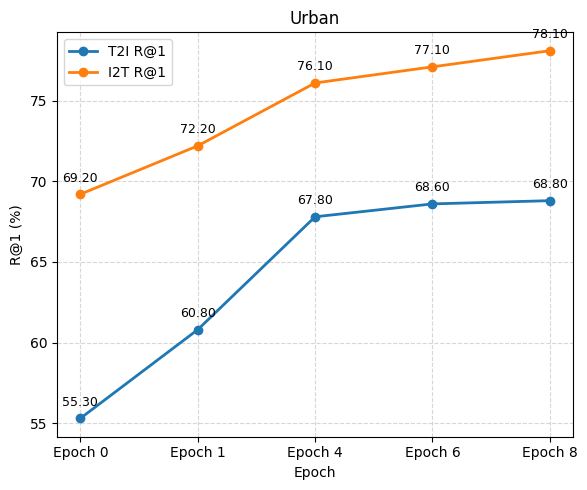

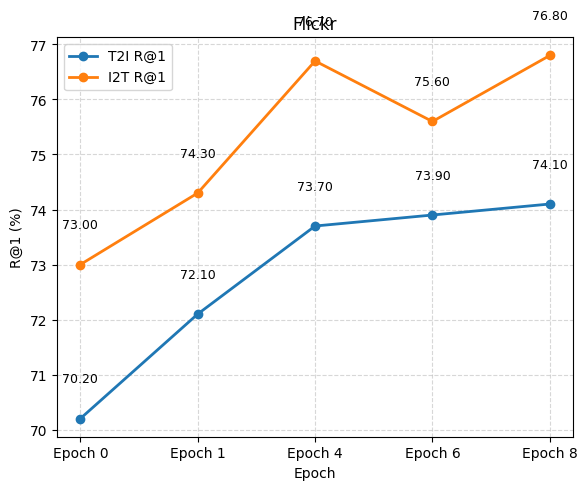

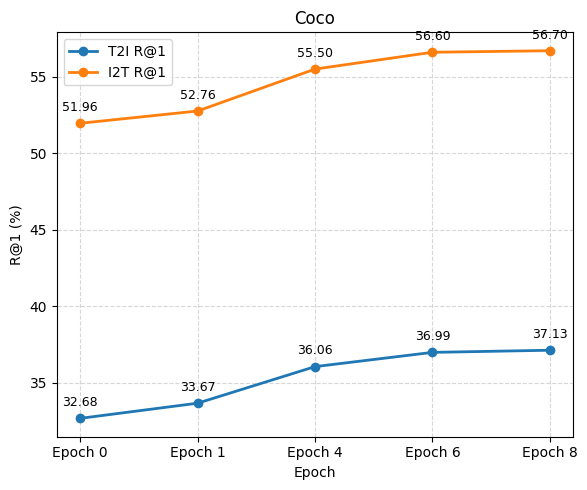

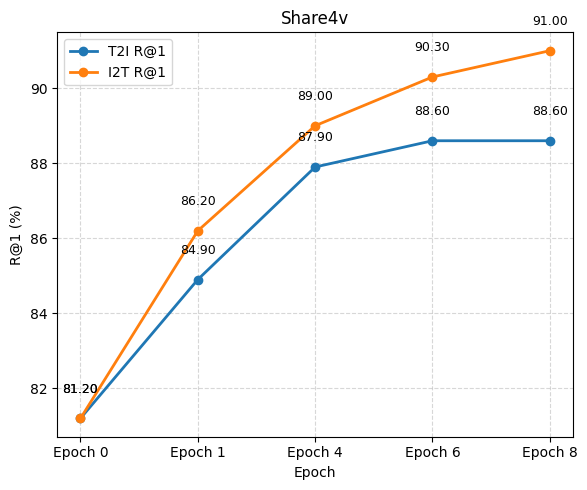

In [77]:
from pathlib import Path
import matplotlib.pyplot as plt

epochs = ["Epoch 0","Epoch 1","Epoch 4","Epoch 6","Epoch 8"]

data = {
    "Urban": {
        "T2I R@1": [55.30, 60.80, 67.80, 68.60, 68.80],
        "I2T R@1": [69.20, 72.20, 76.10, 77.10, 78.10],
    },
    "Flickr": {
        "T2I R@1": [70.20, 72.10, 73.70, 73.90, 74.10],
        "I2T R@1": [73.00, 74.30, 76.70, 75.60, 76.80],
    },
    "Coco": {
        "T2I R@1": [32.68, 33.67, 36.06, 36.99, 37.13],
        "I2T R@1": [51.96, 52.76, 55.50, 56.60, 56.70],
    },
    "Share4v": {
        "T2I R@1": [81.20, 84.90, 87.90, 88.60, 88.60],
        "I2T R@1": [81.20, 86.20, 89.00, 90.30, 91.00],
    },
}

def plot_dataset(name, series_dict, xlabels, outdir: Path):
    x = list(range(len(xlabels)))
    plt.figure(figsize=(6,5))
    for label, values in series_dict.items():
        plt.plot(x, values, marker="o", linewidth=2, label=label)
        for xi, yi in zip(x, values):
            plt.text(xi, yi + 0.6, f"{yi:.2f}", ha="center", va="bottom", fontsize=9)
    plt.title(name)
    plt.xlabel("Epoch")
    plt.ylabel("R@1 (%)")
    plt.xticks(x, xlabels, rotation=0)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(loc="best", frameon=True)
    plt.tight_layout()
    out = outdir / f"{name}_epochs_linechart.png"
    plt.savefig(out, dpi=200)
    return out

def main():
    outdir = Path("./charts_epochs")
    outdir.mkdir(parents=True, exist_ok=True)
    outs = []
    for dataset, series in data.items():
        outs.append(plot_dataset(dataset, series, epochs, outdir))
    print("Saved charts:")
    for p in outs:
        print(p.resolve())

if __name__ == "__main__":
    main()